Charger les bibliothèques et réglages communs

In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

Charger des bibliothèques supplémentaires

In [3]:
import tsfeatures as tsf
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

mpl.rcParams['axes.prop_cycle'] = cycler(color=["#D55F03", "#569CC6", "#13A076", "#CC79A7"])

## Caractéristiques des séries temporelles

Le package **Nixtla** permet de calculer différentes caractéristiques à partir de séries temporelles. Il constitue l’équivalent Python du package R [`tsfeatures`](https://pkg.robjhyndman.com/tsfeatures/).

Une caractéristique est un **résumé numérique calculé à partir d’une série temporelle**. Par exemple :

- les **autocorrélations** ;
- l’**estimation de Guerrero** du paramètre de transformation de Box-Cox ;
- différentes statistiques permettant de décrire les propriétés d’une série.

Le calcul de ces caractéristiques sur plusieurs séries temporelles permet de **comparer, explorer et mieux comprendre leurs comportements**.

Dans ce chapitre, nous étudierons plusieurs caractéristiques utiles pour l’analyse des séries temporelles, en utilisant comme exemple le **tourisme trimestriel australien**.

## Quelques statistiques simples

Tout résumé numérique calculé à partir d’une série temporelle peut être considéré comme une **caractéristique de cette série**  la moyenne, le minimum ou le maximum, par exemple.

Ces caractéristiques peuvent être calculées à l’aide des fonctions natives de **`pandas`**.

Par exemple, calculons la **moyenne de toutes les séries temporelles** présentes dans les données du tourisme australien.

In [4]:
aus_tourism = pd.read_csv("data/aus_tourism.csv", parse_dates=["ds"])
mean_df = aus_tourism.groupby("unique_id", as_index=False)["y"].mean()
mean_df.sort_values(by="y").head(10)

,unique_id,y
158,Kangaroo Island-South Australia-Other,0.340
182,MacDonnell-Northern Territory-Other,0.449
294,Wilderness West-Tasmania-Other,0.478
34,Barkly-Northern Territory-Other,0.632
86,Clare Valley-South Australia-Other,0.898
38,Barossa-South Australia-Other,1.022
154,Kakadu Arnhem-Northern Territory-Other,1.043
170,Lasseter-Northern Territory-Other,1.136
298,Wimmera-Victoria-Other,1.146
183,MacDonnell-Northern Territory-Visiting,1.175


## Quelques statistiques simples

Ici, on voit que la série avec le **moins de visites moyennes** correspond aux visites « Autres » à **Kangaroo Island**, en Australie-Méridionale.

Plutôt que de calculer une caractéristique à la fois, il est pratique de calculer **plusieurs caractéristiques simultanément**.

Un résumé courant d’un ensemble de données consiste à calculer cinq statistiques descriptives :

- **Minimum**
- **Premier quartile (Q1)**
- **Médiane (Q2)**
- **Troisième quartile (Q3)**
- **Maximum**

Ces cinq valeurs constituent le **résumé à cinq nombres** (*five-number summary*). Elles permettent de diviser les données en quatre sections, chacune représentant environ **25 % des observations**.

La fonction `describe()` de **pandas** permet de calculer automatiquement plusieurs statistiques descriptives :



In [5]:
summary_stats = tsf.tsfeatures(aus_tourism,
    freq=4, features=[tsf.statistics], scale=False)
summary_stats[["unique_id", "min", "p25", "median", "p75", "max"]].head(10)

,unique_id,min,p25,median,p75,max
0,Adelaide Hills-South Australia-Business,0.000,0.000,1.255,3.920,28.602
1,Adelaide Hills-South Australia-Holiday,0.000,5.768,8.516,14.060,35.751
2,Adelaide Hills-South Australia-Other,0.000,0.000,0.908,2.093,8.953
3,Adelaide Hills-South Australia-Visiting,0.778,8.908,12.207,16.806,81.102
4,Adelaide-South Australia-Business,68.725,133.893,152.577,176.936,242.494
5,Adelaide-South Australia-Holiday,108.033,134.627,153.945,172.257,223.557
6,Adelaide-South Australia-Other,25.902,43.866,53.809,62.523,107.495
7,Adelaide-South Australia-Visiting,136.611,178.916,205.582,229.299,269.536
8,Alice Springs-Northern Territory-Business,1.008,9.133,13.324,18.456,34.077
9,Alice Springs-Northern Territory-Holiday,2.809,16.851,31.524,44.784,76.541


Les **autocorrélations** permettent de mesurer la relation entre les valeurs décalées d’une série temporelle. Toutes les autocorrélations d’une série peuvent être considérées comme des **caractéristiques de cette série**.

Nous pouvons également résumer les autocorrélations afin de produire de nouvelles caractéristiques. Par exemple, la **somme des carrés des dix premiers coefficients d’autocorrélation** constitue un résumé utile de la quantité d’autocorrélation présente dans une série, quel que soit le décalage (*lag*).

Nous pouvons également calculer les autocorrélations des **changements dans la série entre les périodes**. Pour cela, nous différencions les données afin de créer une nouvelle série temporelle composée des différences entre les observations consécutives. Nous pouvons ensuite calculer les autocorrélations de cette nouvelle série différenciée.

Dans certains cas, il est utile d’appliquer une deuxième différenciation afin de calculer les différences entre les différences. Les autocorrélations de cette série **deux fois différenciée** peuvent fournir des informations supplémentaires.

Une autre approche consiste à calculer les **différences saisonnières** d’une série. Par exemple, pour des données mensuelles, nous pouvons calculer la différence entre des mois de janvier consécutifs, des mois de février consécutifs, et ainsi de suite. Cela permet d’observer comment la série évolue **d’une année à l’autre**, plutôt que d’un mois à l’autre.

Les autocorrélations des séries différenciées saisonnièrement peuvent également fournir des informations utiles.

Le paramètre `features=[acf_features]` permet de calculer une sélection des caractéristiques d’autocorrélation présentées ci-dessus. Il retourne **six caractéristiques** pour les données non saisonnières :

- le premier coefficient d’autocorrélation à partir des données originales ;
- la somme des carrés des dix premiers coefficients d’autocorrélation à partir des données originales ;
- le premier coefficient d’autocorrélation à partir des données différenciées ;
- la somme des carrés des dix premiers coefficients d’autocorrélation à partir des données différenciées ;
- le premier coefficient d’autocorrélation à partir des données deux fois différenciées ;
- la somme des carrés des dix premiers coefficients d’autocorrélation à partir des données deux fois différenciées.

Pour les **données saisonnières**, une septième caractéristique est également retournée :

- le coefficient d’autocorrélation au **premier décalage saisonnier**.

In [6]:
acf_feat = tsf.tsfeatures(aus_tourism, freq=4, features=[tsf.acf_features])
acf_feat.head(10).iloc[:, :5]

,unique_id,x_acf1,x_acf10,diff1_acf1,diff1_acf10
0,Adelaide Hills-South Australia-Business,0.071,0.134,-0.580,0.415
1,Adelaide Hills-South Australia-Holiday,0.131,0.313,-0.536,0.500
2,Adelaide Hills-South Australia-Other,0.261,0.330,-0.253,0.317
3,Adelaide Hills-South Australia-Visiting,0.139,0.117,-0.472,0.239
4,Adelaide-South Australia-Business,0.033,0.131,-0.520,0.463
5,Adelaide-South Australia-Holiday,0.046,0.372,-0.343,0.614
6,Adelaide-South Australia-Other,0.517,1.154,-0.409,0.383
7,Adelaide-South Australia-Visiting,0.068,0.294,-0.394,0.452
8,Alice Springs-Northern Territory-Business,0.217,0.367,-0.500,0.381
9,Alice Springs-Northern Territory-Holiday,-0.007,2.113,-0.153,2.113


# Fonctionnalités STL

La décomposition STL est la base de plusieurs autres caractéristiques.

Une décomposition par série temporelle peut être utilisée pour mesurer la force de la tendance et de la saisonnalité dans une série chronologique.

Rappelons que la décomposition s’écrit comme :

```math
y_t = T_t + S_t + R_t
```

où `T_t` est la composante de tendance lissée, `S_t` est la composante saisonnière et `R_t` est la composante résiduelle.

## Force de la tendance

Pour les données fortement tendancielles, les données désaisonnalisées devraient présenter beaucoup plus de variation que la composante résiduelle.

Donc :

```math
\frac{\operatorname{Var}(R_t)}
{\operatorname{Var}(T_t + R_t)}
```

devrait être relativement petit.

Mais pour des données avec peu ou pas de tendance, les deux variances devraient être à peu près identiques.

Nous définissons donc la **force de la tendance** comme suit :

```math
F_T =
\max\left(
0,\,
1 -
\frac{\operatorname{Var}(R_t)}
{\operatorname{Var}(T_t + R_t)}
\right)
```

Cela donne une mesure de la force de la tendance comprise entre **0 et 1**.

Comme la variance du reste peut parfois être même plus grande que la variance des données désaisonnalisées, nous fixons la valeur minimale possible de `F_T` à zéro.

## Force de la saisonnalité

La force de la saisonnalité est définie de manière similaire, mais en fonction des données détendancées plutôt que des données désaisonnalisées :

```math
F_S =
\max\left(
0,\,
1 -
\frac{\operatorname{Var}(R_t)}
{\operatorname{Var}(S_t + R_t)}
\right)
```

Une série avec une force saisonnière `F_S` proche de zéro présente presque aucune saisonnalité, tandis qu’une série avec une forte saisonnalité aura une valeur de `F_S` proche de 1, car :

```math
\operatorname{Var}(R_t)
\ll
\operatorname{Var}(S_t + R_t)
```

## Utilité des mesures

Ces mesures peuvent être utiles, par exemple, lorsque vous disposez d’une grande collection de séries temporelles et que vous devez trouver :

* la série avec la plus grande tendance ;
* la série avec la plus forte saisonnalité.

Ces caractéristiques et d’autres caractéristiques basées sur STL sont calculées en utilisant :

```python
features = [stl_features]
```


In [7]:
stl_feat = tsf.tsfeatures(aus_tourism, freq=4, features=[tsf.stl_features])
stl_feat.head(10).iloc[:, :5]

,unique_id,nperiods,seasonal_period,trend,spike
0,Adelaide Hills-South Australia-Business,1,4,0.460,3.223e-04
1,Adelaide Hills-South Australia-Holiday,1,4,0.531,1.048e-04
2,Adelaide Hills-South Australia-Other,1,4,0.590,5.346e-05
3,Adelaide Hills-South Australia-Visiting,1,4,0.487,5.798e-04
4,Adelaide-South Australia-Business,1,4,0.462,9.712e-05
5,Adelaide-South Australia-Holiday,1,4,0.578,1.717e-05
6,Adelaide-South Australia-Other,1,4,0.746,2.364e-05
7,Adelaide-South Australia-Visiting,1,4,0.449,4.824e-05
8,Alice Springs-Northern Territory-Business,1,4,0.552,5.246e-05
9,Alice Springs-Northern Territory-Holiday,1,4,0.379,6.707e-06


Nous pouvons ensuite représenter ces caractéristiques graphiquement afin d’identifier les séries présentant les tendances et les saisonnalités les plus marquées

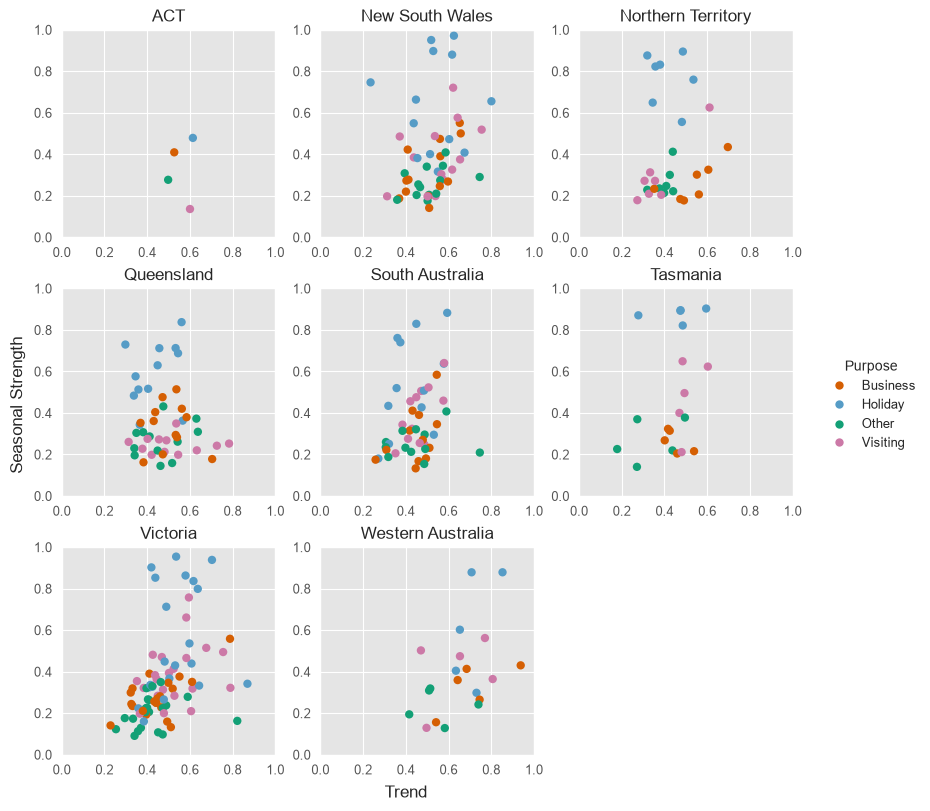

In [8]:
df = (
    stl_feat["unique_id"].str.split("-", expand=True)
    .rename(columns={0: "region", 1: "state", 2: "purpose"})
    .join(stl_feat)
)
fig, axs = plt.subplots(3, 3, figsize=(8, 8))
axs = axs.flatten()
for ax, (state, state_df) in zip(axs, df.groupby('state')):
    sns.scatterplot(x="trend", y="seasonal_strength",
        hue="purpose", edgecolor="none", data=state_df, ax=ax)
    ax.get_legend().remove()
    ax.set(title=state, xlabel="", ylabel="", xlim=(0, 1), ylim=(0, 1))
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
    title="Purpose", loc="center left", frameon=False,
    bbox_to_anchor=(1.02, .5), borderaxespad=0)
fig.supxlabel('Trend')
fig.supylabel('Seasonal Strength')

# Remove any empty subplots
for ax in axs:
    if not ax.lines:
        ax.set_visible(False)

Figure: Force saisonnière vs force de tendance pour toutes les séries touristiques.

Clairement, les séries de vacances sont très saisonnières, ce qui n’est pas surprenant. Les tendances les plus marquées se situent généralement en Australie-Occidentale et dans le Victoria. Les séries les plus saisonnières peuvent également être facilement identifiées et tracées.

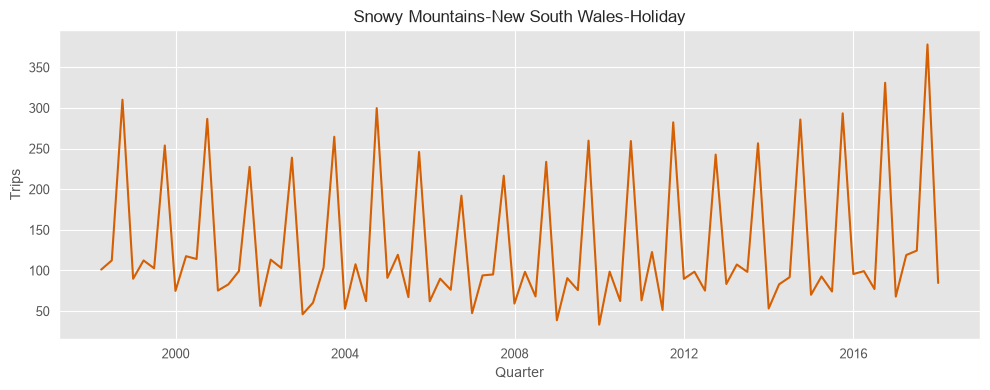

In [10]:
row = stl_feat.loc[stl_feat["seasonal_strength"].idxmax()]

serie = aus_tourism[
    aus_tourism["unique_id"] == row["unique_id"]
]

plt.figure(figsize=(10, 4))

plt.plot(
    serie["ds"],
    serie["y"],
    linewidth=1.5
)

plt.xlabel("Quarter")
plt.ylabel("Trips")
plt.title(row["unique_id"])

plt.tight_layout()
plt.show()

Figure: La série la plus saisonnière dans les données touristiques australiennes

On y voit des voyages de vacances dans la région de ski la plus populaire d’Australie.

La fonction `stl_features()` renvoie plusieurs autres caractéristiques en plus de celles évoquées ci-dessus :

- `peak` indique le moment des pics, c’est-à-dire le mois ou le trimestre qui contient la plus grande composante saisonnière. Cela nous renseigne sur la nature de la saisonnalité. Dans les données touristiques australiennes, si le troisième trimestre constitue la période saisonnière de pointe, les voyages dans la région ont principalement lieu en hiver, tandis qu’un pic au premier trimestre suggère que la région est plus populaire en été.

- `trough` indique le moment des creux, c’est-à-dire le mois ou le trimestre qui contient la plus petite composante saisonnière.

- `spike` mesure la prévalence des pics dans le reste de la composante `Rt` de la décomposition STL. Il correspond à la variance des variances calculées en laissant successivement une observation de côté.

- `linearity` mesure la linéarité de la composante de tendance de la décomposition STL. Elle est basée sur le coefficient d’une régression linéaire appliquée à la composante de tendance.

- `curvature` mesure la courbure de la composante de tendance de la décomposition STL. Elle est basée sur le coefficient d’une régression quadratique orthogonale appliquée à la composante de tendance.

- `e_acf1` correspond au premier coefficient d’autocorrélation de la série des résidus.

- `e_acf10` correspond à la somme des carrés des dix premiers coefficients d’autocorrélation de la série des résidus.

## Autres fonctionnalités

Beaucoup plus de fonctionnalités sont possibles, et la bibliothèque `tsfeatures` ne calcule que quelques dizaines de fonctionnalités qui se sont révélées utiles pour l’analyse des séries temporelles. Il est également facile d’ajouter ses propres fonctionnalités en écrivant une fonction Python qui prend en entrée une série temporelle univariée et renvoie un vecteur numérique contenant les valeurs des caractéristiques.

Les autres fonctionnalités de la bibliothèque, non évoquées précédemment, sont listées ici pour référence. Les détails de certaines d’entre elles sont abordés plus tard dans le livre.

- `hurst` calcule le coefficient de Hurst d’une série temporelle, qui est une mesure de la « mémoire longue ». Une série à mémoire longue présente des autocorrélations significatives pour de nombreux décalages.

- `feat_spectral` calcule l’entropie spectrale (de Shannon) d’une série temporelle, qui mesure la facilité de prévision de la série. Une série présentant une forte tendance et une forte saisonnalité, et donc facile à prévoir, aura une entropie proche de zéro. Une série très bruitée, et donc difficile à prévoir, aura une entropie proche de 1.

- `box_pierce` donne la statistique de Box-Pierce permettant de tester si une série temporelle est un bruit blanc, ainsi que la valeur p correspondante.

- `ljung_box` donne la statistique de Ljung-Box permettant de tester si une série temporelle est un bruit blanc, ainsi que la valeur p correspondante.

- `feat_pacf()` calcule plusieurs caractéristiques impliquant les autocorrélations partielles. L’autocorrélation partielle au décalage `k` mesure la relation entre les observations séparées de `k` périodes, après avoir supprimé les effets des observations intermédiaires. Ainsi, la première autocorrélation partielle (`k=1`) est identique à la première autocorrélation, car il n’y a aucune observation intermédiaire à prendre en compte. La fonction inclut notamment la somme des carrés des cinq premières autocorrélations partielles pour la série originale, la première série différenciée et la deuxième série différenciée. Pour les données saisonnières, elle inclut également l’autocorrélation partielle au premier décalage saisonnier.

- `n_crossing_points` calcule le nombre de fois où une série temporelle traverse sa médiane.

- `stat_arch_lm` renvoie la statistique basée sur le test du multiplicateur de Lagrange (LM) d’Engle (1982) pour l’hétéroscédasticité conditionnelle autorégressive (ARCH).

- `guerrero` calcule la valeur optimale de `λ` pour une transformation de Box-Cox utilisant la méthode de Guerrero.

### Explorer les données sur le tourisme australien

Toutes les fonctionnalités incluses dans la bibliothèque `tsfeatures` peuvent être calculées simultanément de cette façon.

In [11]:
all_features = [
    tsf.acf_features,
    tsf.arch_stat,
    tsf.crossing_points,
    tsf.entropy,
    tsf.flat_spots,
    tsf.heterogeneity,
    tsf.holt_parameters,
    tsf.lumpiness,
    tsf.nonlinearity,
    tsf.pacf_features,
    tsf.stl_features,
    tsf.stability,
    tsf.hw_parameters,
    tsf.unitroot_kpss,
    tsf.unitroot_pp,
    tsf.series_length,
    tsf.hurst,
]
all_feat = tsf.tsfeatures(aus_tourism, freq=4, features=all_features)
all_feat.head(10)

,unique_id,hurst,series_length,unitroot_pp,unitroot_kpss,hw_alpha,hw_beta,hw_gamma,stability,nperiods,...,entropy,crossing_points,arch_lm,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,Adelaide Hills-South Australia-Business,NaN,80,-80.527,0.060,1.490e-08,1.220e-08,0.00,0.294,1,...,0.895,36,0.014,0.071,0.134,-0.580,0.415,-0.750,0.746,-0.063
1,Adelaide Hills-South Australia-Holiday,0.823,80,-74.302,0.476,9.899e-02,9.899e-02,0.00,0.409,1,...,0.831,33,0.121,0.131,0.313,-0.536,0.500,-0.716,0.906,0.208
2,Adelaide Hills-South Australia-Other,0.599,80,-55.385,0.605,1.490e-08,1.481e-08,0.18,0.274,1,...,0.862,37,0.265,0.261,0.330,-0.253,0.317,-0.457,0.392,0.075
3,Adelaide Hills-South Australia-Visiting,0.757,80,-71.076,0.749,1.490e-08,1.150e-09,0.00,0.333,1,...,0.907,25,0.005,0.139,0.117,-0.472,0.239,-0.626,0.408,0.170
4,Adelaide-South Australia-Business,0.840,80,-78.764,0.221,1.306e-01,1.306e-01,0.00,0.318,1,...,0.848,43,0.183,0.033,0.131,-0.520,0.463,-0.676,0.741,0.201
5,Adelaide-South Australia-Holiday,0.709,80,-72.567,0.449,1.758e-01,1.758e-01,0.00,0.312,1,...,0.737,36,0.161,0.046,0.372,-0.343,0.614,-0.487,0.558,0.351
6,Adelaide-South Australia-Other,0.776,80,-36.405,1.406,1.068e-01,7.715e-02,0.00,0.574,1,...,0.755,28,0.456,0.517,1.154,-0.409,0.383,-0.675,0.792,0.342
7,Adelaide-South Australia-Visiting,0.737,80,-74.137,0.264,1.630e-01,0.000e+00,0.00,0.267,1,...,0.776,42,0.173,0.068,0.294,-0.394,0.452,-0.518,0.447,0.345
8,Alice Springs-Northern Territory-Business,0.673,80,-65.845,0.807,1.456e-01,0.000e+00,0.00,0.439,1,...,0.851,33,0.425,0.217,0.367,-0.500,0.381,-0.658,0.587,0.315
9,Alice Springs-Northern Territory-Holiday,0.579,80,-54.382,0.387,1.490e-08,7.910e-09,0.00,0.084,1,...,0.412,40,0.304,-0.007,2.113,-0.153,2.113,-0.274,1.551,0.729


Cela donne 42 caractéristiques pour chaque combinaison des trois variables clés (`Region`, `State` et `Purpose`). Nous pouvons traiter ce dataframe comme n’importe quel ensemble de données et l’analyser pour trouver des observations ou des groupes d’observations intéressants.

Nous avons déjà vu comment comparer une caractéristique à une autre. Nous pouvons également réaliser des diagrammes par paires de groupes de caractéristiques. Par exemple, nous pouvons représenter toutes les caractéristiques liées à la saisonnalité, ainsi que la variable `Purpose`.

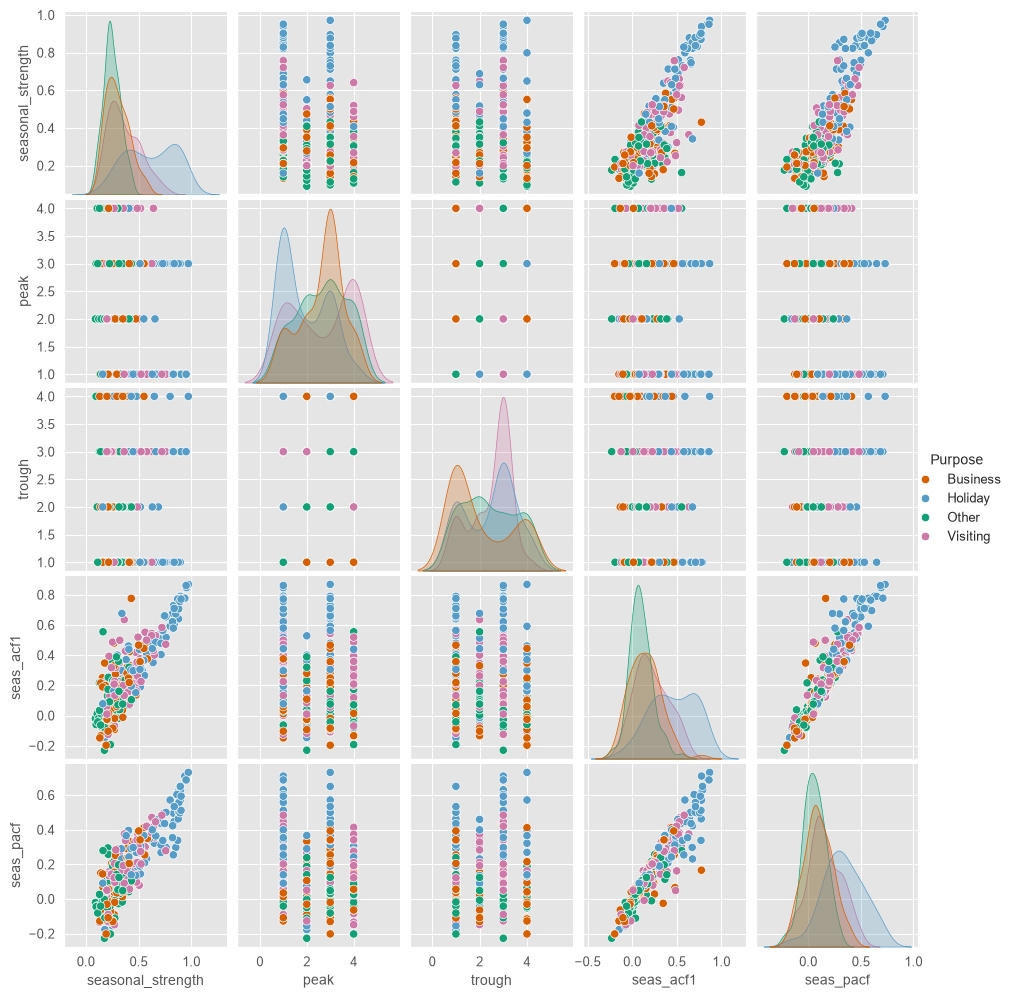

In [12]:
seasonal_feat = all_feat[
    ["unique_id", "seasonal_strength", "peak", "trough",
     "seas_acf1", "seas_pacf"]
]
df = (
    seasonal_feat["unique_id"].str.split("-", expand=True)
    .rename(columns={0: "region", 1: "state", 2: "Purpose"})
    .join(seasonal_feat)
)
g = sns.pairplot(df, hue="Purpose")
g.fig.set_size_inches(10, 10)
plt.show()

Figure: Graphiques par paires de toutes les caractéristiques saisonnières pour les données touristiques australiennes

Ici, la variable `Purpose` est représentée par la couleur. Cette représentation contient beaucoup d’informations, mais nous allons nous concentrer sur quelques éléments importants :

- Les trois mesures numériques liées à la saisonnalité (`seasonal_strength`, `seasonal_acf1` et `seasonal_pacf`) sont toutes positivement corrélées.
- Les graphiques en bas à gauche et en haut à droite montrent que les séries les plus saisonnières sont fortement associées aux voyages de vacances, comme nous l’avons vu précédemment.
- Les graphiques en barres de la dernière ligne, pour les variables `peak` et `trough`, montrent que les pics saisonniers des déplacements d’affaires se produisent le plus souvent au troisième trimestre et le moins souvent au premier trimestre.

Il est difficile d’explorer plus qu’une poignée de variables de cette manière. Une approche utile pour gérer un grand nombre de variables consiste à utiliser une technique de réduction de dimension, telle que l’analyse en composantes principales (ACP).

Cette méthode permet de créer des combinaisons linéaires des variables qui expliquent la plus grande partie de la variation présente dans les données originales. Nous pouvons calculer les principales composantes des caractéristiques touristiques comme suit.

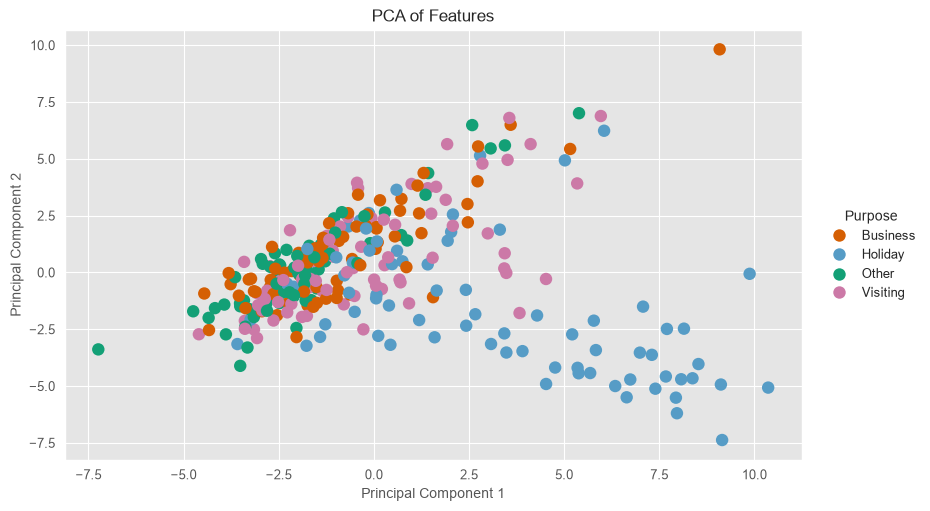

In [13]:
df = (
    all_feat
    .assign(purpose=lambda x: x["unique_id"].str.split("-").str[-1])
    .dropna(axis='columns')
)
X = df.drop(columns=["unique_id", "purpose"])
pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=2)),
])
principal_components = pipeline.fit_transform(X)
pca_df = (
    pd.DataFrame(data=principal_components, columns=["PC1", "PC2"])
    .join(df[["unique_id", "purpose"]])
)
fig, ax = plt.subplots()
sns.scatterplot(x="PC1", y="PC2", s=80,
    hue="purpose", edgecolor="none", data=pca_df, ax=ax)
ax.set(
    title="PCA of Features",
    xlabel="Principal Component 1",
    ylabel="Principal Component 2",
)
ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
    title="Purpose", loc="center left", frameon=False,
    bbox_to_anchor=(1.02, .5), borderaxespad=0)
plt.show()

Figure: Un graphique des deux premiers composantes principales, calculé à partir des 37 caractéristiques des données trimestrielles australiennes sur le tourisme

Chaque point représente une série et sa position sur le graphique est basée sur les 37 caractéristiques. La première composante principale (`PC1`) est la combinaison linéaire des caractéristiques qui explique la plus grande variation des données. La deuxième composante principale (`PC2`) est la combinaison linéaire qui explique la variation suivante dans les données, tout en étant non corrélée avec la première composante principale.

Pour plus d’informations sur la réduction de dimension par les composantes principales, voir Izenman (2008).

La représentation révèle quelques éléments intéressants sur les données touristiques. Premièrement, la série de Noël se comporte très différemment du reste des séries. Presque toutes les séries de Noël apparaissent dans la moitié inférieure du graphique, tandis que presque toutes les autres séries apparaissent dans la moitié supérieure. De toute évidence, la deuxième composante principale permet de distinguer les voyages de vacances des autres types de voyages.

La représentation permet également d’identifier des séries temporelles anormales, c’est-à-dire des séries présentant des combinaisons de caractéristiques inhabituelles. Elles apparaissent comme des points éloignés de la majorité des séries. Trois séries se démarquent particulièrement, et nous pouvons identifier les séries auxquelles elles correspondent.

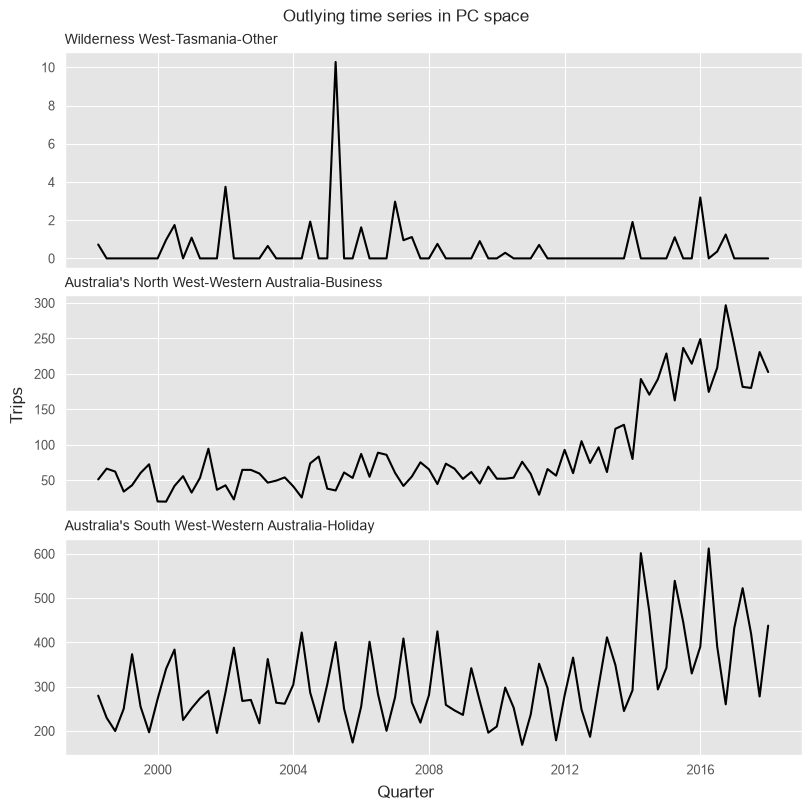

In [14]:
lof = LocalOutlierFactor(n_neighbors=10).fit(pca_df[["PC1", "PC2"]])
res = pca_df.assign(score=lof.negative_outlier_factor_)
selected_ids = res.sort_values("score")["unique_id"].head(3)

fig, axs = plt.subplots(3, figsize=(8, 8), sharex=True)
for (ax, unique_id) in zip(axs, selected_ids):
    df = aus_tourism.loc[lambda x: x["unique_id"] == unique_id]
    ax.plot(df["ds"], df["y"], color="k")
    ax.set_title(unique_id, loc="left", size="medium")

fig.suptitle("Outlying time series in PC space")
fig.supylabel("Trips")
fig.supxlabel("Quarter")
plt.show()

Figure: Trois séries temporelles anormales issues des données touristiques australienne

Nous pouvons supposer que ces séries sont considérées comme inhabituelles pour plusieurs raisons :

- Le Far West de la Tasmanie compte très peu de visiteurs, mais une exception apparaît en 2005 pour la catégorie « autres visites ».

- Le nord-ouest de l’Australie-Occidentale est inhabituel en raison d’une forte augmentation des visites d’affaires ces dernières années, probablement liée à l’activité minière, mais avec peu ou pas de saisonnalité.

- Le sud-ouest de l’Australie-Occidentale est également inhabituel, car les données montrent une augmentation du tourisme de vacances ces dernières années, accompagnée d’un niveau élevé de saisonnalité.